# Notebook 6 — Data Efficiency Experiment

## Research Question 2

> **How does training-data size affect the performance of TF-IDF, BiLSTM, and DistilBERT?**

Training fractions: **10%, 25%, 50%, 75%, 100%**.

For each fraction, a new model is trained from scratch. The training subsets are **nested and stratified**: the 10% subset is contained in the 25% subset, which is contained in the 50% subset, and so on. The validation and test sets remain fixed throughout the experiment.

### Fair-comparison principles
- Same prepared dataset for all models
- Same fixed validation and test sets
- Same nested training subsets
- Same random seed and controlled DataLoader shuffling
- Same evaluation metrics
- Macro F1 is the primary metric
- Class-weighted training is used for all three models
- No test-set tuning
- Each model is initialized and trained independently for every data fraction


## 1. Imports and reproducibility

In [1]:
from pathlib import Path
import gc
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

RANDOM_STATE = 42

def set_seed(seed=RANDOM_STATE):
    """Set random seeds so each experiment can be reproduced."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 2. Load the fixed train, validation and test sets

These files were created in `02_dataset_preparation.ipynb`. The validation and test sets are never reduced in this experiment.

In [2]:
possible_dirs = [Path("data/prepared"), Path("../data/prepared")]

DATA_DIR = None
for directory in possible_dirs:
    if (directory / "train.csv").exists():
        DATA_DIR = directory
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find data/prepared/train.csv. Please run 02_dataset_preparation.ipynb first."
    )

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "validation.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


Train: (38115, 2)
Validation: (8167, 2)
Test: (8168, 2)


## 3. Label mapping and experiment settings

In [3]:
labels = sorted(train_df["label"].unique())

label_to_id = {label: i for i, label in enumerate(labels)}
id_to_label = {i: label for label, i in label_to_id.items()}

print("Labels:")
for label, label_id in label_to_id.items():
    print(label_id, "->", label)

FRACTIONS = [0.10, 0.25, 0.50, 0.75, 1.00]
print("\nTraining fractions:", FRACTIONS)


Labels:
0 -> Anxiety
1 -> Depression
2 -> Happy
3 -> Mentalhealth
4 -> Normal
5 -> Sad
6 -> Stress
7 -> Suicidal

Training fractions: [0.1, 0.25, 0.5, 0.75, 1.0]


## 4. Create nested stratified training subsets

A fixed random ordering is created separately inside each class. For every fraction, we take the required prefix of that ordering. This guarantees that the subsets are nested.

In [4]:
def make_nested_subsets(dataframe, fractions, seed=42):
    class_groups = {
        label: group.index.to_numpy()
        for label, group in dataframe.groupby("label", sort=True)
    }

    rng = np.random.RandomState(seed)
    shuffled_indices = {}

    for label, indices in class_groups.items():
        shuffled = indices.copy()
        rng.shuffle(shuffled)
        shuffled_indices[label] = shuffled

    subsets = {}

    for fraction in fractions:
        selected_indices = []

        for label in labels:
            indices = shuffled_indices[label]
            n = max(int(round(len(indices) * fraction)), 1)
            selected_indices.extend(indices[:n])

        selected_indices = np.array(selected_indices)
        rng.shuffle(selected_indices)
        subsets[fraction] = dataframe.loc[selected_indices].reset_index(drop=True)

    return subsets

train_subsets = make_nested_subsets(train_df, FRACTIONS, RANDOM_STATE)

print("Training subset sizes:")
for fraction, subset in train_subsets.items():
    print(f"{fraction:.0%}: {len(subset):,} training examples")


Training subset sizes:
10%: 3,811 training examples
25%: 9,529 training examples
50%: 19,058 training examples
75%: 28,586 training examples
100%: 38,115 training examples


## 5. Verify stratification

In [5]:
distribution_table = pd.DataFrame(index=labels)

for fraction, subset in train_subsets.items():
    distribution_table[f"{fraction:.0%}"] = (
        subset["label"].value_counts(normalize=True).reindex(labels)
    )

display(distribution_table.round(4))


,10%,25%,50%,75%,100%
Anxiety,0.0840,0.0840,0.0840,0.0840,0.0840
Depression,0.2907,0.2907,0.2907,0.2907,0.2907
Happy,0.0126,0.0126,0.0126,0.0126,0.0126
Mentalhealth,0.0357,0.0357,0.0357,0.0357,0.0357
Normal,0.2944,0.2945,0.2944,0.2944,0.2944
Sad,0.0302,0.0301,0.0301,0.0301,0.0301
Stress,0.0420,0.0421,0.0421,0.0421,0.0421
Suicidal,0.2104,0.2104,0.2104,0.2104,0.2104


In [6]:
# Verify that the training subsets are nested.
fractions_in_order = sorted(FRACTIONS)

for smaller, larger in zip(fractions_in_order[:-1], fractions_in_order[1:]):
    smaller_texts = set(train_subsets[smaller]["text"])
    larger_texts = set(train_subsets[larger]["text"])
    assert smaller_texts.issubset(larger_texts)

print("Nested-subset check passed: each smaller training subset is contained in the next larger subset.")


Nested-subset check passed: each smaller training subset is contained in the next larger subset.


### Interpretation note

The 10% condition is a low-data setting and contains substantially fewer examples for the minority classes. Its result should therefore be interpreted as evidence about performance under limited training data, not as a precise estimate of the model's general performance with very small datasets.


# Part A — TF-IDF + Logistic Regression

This follows the main baseline configuration from Notebook 3.

In [7]:
TFIDF_CONFIG = {
    "lowercase": True,
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.95,
    "sublinear_tf": True,
    "max_features": 100000,
}

LOGISTIC_CONFIG = {
    "max_iter": 1000,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
}

def evaluate_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


In [8]:
tfidf_results = []

for fraction, subset in train_subsets.items():
    print(f"\nRunning TF-IDF with {fraction:.0%} of training data...")
    start_time = time.time()

    vectorizer = TfidfVectorizer(**TFIDF_CONFIG)

    X_train = vectorizer.fit_transform(subset["text"].astype(str))
    X_val = vectorizer.transform(val_df["text"].astype(str))
    X_test = vectorizer.transform(test_df["text"].astype(str))

    model = LogisticRegression(**LOGISTIC_CONFIG)
    model.fit(X_train, subset["label"])

    val_metrics = evaluate_predictions(
        val_df["label"], model.predict(X_val)
    )
    test_metrics = evaluate_predictions(
        test_df["label"], model.predict(X_test)
    )

    elapsed = time.time() - start_time

    tfidf_results.append({
        "model": "TF-IDF + Logistic Regression",
        "fraction": fraction,
        "n_train": len(subset),
        "val_macro_f1": val_metrics["macro_f1"],
        "test_accuracy": test_metrics["accuracy"],
        "test_macro_precision": test_metrics["macro_precision"],
        "test_macro_recall": test_metrics["macro_recall"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_weighted_f1": test_metrics["weighted_f1"],
        "training_time_seconds": elapsed,
        "n_features": X_train.shape[1],
    })

    print(
        f"Validation Macro F1: {val_metrics['macro_f1']:.4f} | "
        f"Test Macro F1: {test_metrics['macro_f1']:.4f} | "
        f"Time: {elapsed:.1f}s"
    )

    del vectorizer, model, X_train, X_val, X_test
    gc.collect()

tfidf_results_df = pd.DataFrame(tfidf_results)
display(tfidf_results_df.round(4))



Running TF-IDF with 10% of training data...
Validation Macro F1: 0.6352 | Test Macro F1: 0.6257 | Time: 5.6s

Running TF-IDF with 25% of training data...
Validation Macro F1: 0.6559 | Test Macro F1: 0.6587 | Time: 13.8s

Running TF-IDF with 50% of training data...
Validation Macro F1: 0.6799 | Test Macro F1: 0.6817 | Time: 19.4s

Running TF-IDF with 75% of training data...
Validation Macro F1: 0.7006 | Test Macro F1: 0.6921 | Time: 27.7s

Running TF-IDF with 100% of training data...
Validation Macro F1: 0.7073 | Test Macro F1: 0.7022 | Time: 35.7s


,model,fraction,n_train,val_macro_f1,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_f1,training_time_seconds,n_features
0,TF-IDF + Logistic Regression,0.10,3811,0.6352,0.7051,0.6509,0.6309,0.6257,0.7026,5.5638,42899
1,TF-IDF + Logistic Regression,0.25,9529,0.6559,0.7264,0.6635,0.6793,0.6587,0.7259,13.7581,92222
2,TF-IDF + Logistic Regression,0.50,19058,0.6799,0.7379,0.6715,0.7094,0.6817,0.7387,19.3880,100000
3,TF-IDF + Logistic Regression,0.75,28586,0.7006,0.7473,0.6760,0.7257,0.6921,0.7488,27.7437,100000
4,TF-IDF + Logistic Regression,1.00,38115,0.7073,0.7512,0.6832,0.7387,0.7022,0.7524,35.7018,100000


# Part B — BiLSTM

Configuration follows Notebook 4: vocabulary from the current training subset, maximum sequence length 128, 100-dimensional embeddings, 128 hidden units, bidirectional LSTM, mean pooling, dropout 0.3, Adam with learning rate 0.001, 5 epochs, and class-weighted cross-entropy.

In [9]:
MAX_VOCAB_SIZE = 50000
MIN_WORD_FREQ = 2
MAX_SEQ_LEN = 128
BATCH_SIZE = 32
EMBED_DIM = 100
HIDDEN_DIM = 128
DROPOUT = 0.3
BILSTM_LR = 0.001
BILSTM_EPOCHS = 5

def build_vocabulary(dataframe, max_vocab_size=50000, min_freq=2):
    word_counts = {}

    for text in dataframe["text"].astype(str):
        for word in text.lower().split():
            word_counts[word] = word_counts.get(word, 0) + 1

    sorted_words = sorted(word_counts.items(), key=lambda item: item[1], reverse=True)

    vocabulary = {"<PAD>": 0, "<UNK>": 1}

    for word, count in sorted_words:
        if count < min_freq or len(vocabulary) >= max_vocab_size:
            break
        vocabulary[word] = len(vocabulary)

    return vocabulary

def encode_text(text, vocabulary, max_len=128):
    tokens = str(text).lower().split()
    token_ids = [
        vocabulary.get(token, vocabulary["<UNK>"])
        for token in tokens[:max_len]
    ]

    token_ids += [vocabulary["<PAD>"]] * (max_len - len(token_ids))
    return token_ids

class TextDataset(Dataset):
    def __init__(self, dataframe, vocabulary, max_len):
        self.texts = dataframe["text"].astype(str).tolist()
        self.labels = [label_to_id[label] for label in dataframe["label"]]
        self.vocabulary = vocabulary
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        return (
            torch.tensor(
                encode_text(self.texts[index], self.vocabulary, self.max_len),
                dtype=torch.long
            ),
            torch.tensor(self.labels[index], dtype=torch.long)
        )

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size, embedding_dim, padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids):
        embeddings = self.embedding(input_ids)
        outputs, _ = self.lstm(embeddings)

        mask = (input_ids != 0).unsqueeze(-1)
        masked_outputs = outputs * mask
        lengths = mask.sum(dim=1).clamp(min=1)

        pooled = masked_outputs.sum(dim=1) / lengths
        pooled = self.dropout(pooled)

        return self.classifier(pooled)

def evaluate_bilstm(model, data_loader):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for input_ids, labels_batch in data_loader:
            input_ids = input_ids.to(device)
            labels_batch = labels_batch.to(device)

            predictions = torch.argmax(model(input_ids), dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    return all_labels, all_predictions


In [10]:
bilstm_results = []

for fraction, subset in train_subsets.items():
    print(f"\nRunning BiLSTM with {fraction:.0%} of training data...")
    set_seed(RANDOM_STATE)
    loader_generator = torch.Generator()
    loader_generator.manual_seed(RANDOM_STATE)
    start_time = time.time()

    vocabulary = build_vocabulary(
        subset,
        max_vocab_size=MAX_VOCAB_SIZE,
        min_freq=MIN_WORD_FREQ
    )

    train_loader = DataLoader(
        TextDataset(subset, vocabulary, MAX_SEQ_LEN),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=loader_generator
    )
    val_loader = DataLoader(
        TextDataset(val_df, vocabulary, MAX_SEQ_LEN),
        batch_size=BATCH_SIZE,
        shuffle=False
    )
    test_loader = DataLoader(
        TextDataset(test_df, vocabulary, MAX_SEQ_LEN),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model = BiLSTMClassifier(
        vocab_size=len(vocabulary),
        embedding_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        num_classes=len(labels),
        dropout=DROPOUT
    ).to(device)

    class_counts = subset["label"].value_counts().reindex(labels).values
    class_weights = torch.tensor(
        len(subset) / (len(labels) * class_counts),
        dtype=torch.float32,
        device=device
    )

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=BILSTM_LR)

    best_val_f1 = -1.0
    best_state = None

    for epoch in range(BILSTM_EPOCHS):
        model.train()
        running_loss = 0.0

        for input_ids, labels_batch in train_loader:
            input_ids = input_ids.to(device)
            labels_batch = labels_batch.to(device)

            optimizer.zero_grad()
            logits = model(input_ids)
            loss = criterion(logits, labels_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        val_true, val_pred = evaluate_bilstm(model, val_loader)
        val_f1 = f1_score(
            val_true, val_pred, average="macro", zero_division=0
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        print(
            f"Epoch {epoch + 1}/{BILSTM_EPOCHS} | "
            f"Loss: {running_loss / len(train_loader):.4f} | "
            f"Val Macro F1: {val_f1:.4f}"
        )

    model.load_state_dict(best_state)

    test_true, test_pred = evaluate_bilstm(model, test_loader)
    test_metrics = evaluate_predictions(test_true, test_pred)
    elapsed = time.time() - start_time

    bilstm_results.append({
        "model": "BiLSTM",
        "fraction": fraction,
        "n_train": len(subset),
        "val_macro_f1": best_val_f1,
        "test_accuracy": test_metrics["accuracy"],
        "test_macro_precision": test_metrics["macro_precision"],
        "test_macro_recall": test_metrics["macro_recall"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_weighted_f1": test_metrics["weighted_f1"],
        "training_time_seconds": elapsed,
        "vocab_size": len(vocabulary),
    })

    print(
        f"Best Val Macro F1: {best_val_f1:.4f} | "
        f"Test Macro F1: {test_metrics['macro_f1']:.4f} | "
        f"Time: {elapsed / 60:.1f} min"
    )

    del train_loader, val_loader, test_loader
    del model, best_state, optimizer, criterion, class_weights, vocabulary
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

bilstm_results_df = pd.DataFrame(bilstm_results)
display(bilstm_results_df.round(4))



Running BiLSTM with 10% of training data...
Epoch 1/5 | Loss: 1.6866 | Val Macro F1: 0.2907
Epoch 2/5 | Loss: 1.3339 | Val Macro F1: 0.3260
Epoch 3/5 | Loss: 1.1584 | Val Macro F1: 0.4072
Epoch 4/5 | Loss: 0.9631 | Val Macro F1: 0.4286
Epoch 5/5 | Loss: 0.8187 | Val Macro F1: 0.4876
Best Val Macro F1: 0.4876 | Test Macro F1: 0.4931 | Time: 0.2 min

Running BiLSTM with 25% of training data...
Epoch 1/5 | Loss: 1.4975 | Val Macro F1: 0.3418
Epoch 2/5 | Loss: 1.1089 | Val Macro F1: 0.4386
Epoch 3/5 | Loss: 0.9021 | Val Macro F1: 0.5133
Epoch 4/5 | Loss: 0.7287 | Val Macro F1: 0.5588
Epoch 5/5 | Loss: 0.5762 | Val Macro F1: 0.5492
Best Val Macro F1: 0.5588 | Test Macro F1: 0.5500 | Time: 0.3 min

Running BiLSTM with 50% of training data...
Epoch 1/5 | Loss: 1.3476 | Val Macro F1: 0.4545
Epoch 2/5 | Loss: 0.9460 | Val Macro F1: 0.5747
Epoch 3/5 | Loss: 0.7458 | Val Macro F1: 0.5875
Epoch 4/5 | Loss: 0.5910 | Val Macro F1: 0.6110
Epoch 5/5 | Loss: 0.4685 | Val Macro F1: 0.6012
Best Val Macr

,model,fraction,n_train,val_macro_f1,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_f1,training_time_seconds,vocab_size
0,BiLSTM,0.10,3811,0.4876,0.5889,0.4849,0.5510,0.4931,0.5858,13.8164,10788
1,BiLSTM,0.25,9529,0.5588,0.6283,0.5263,0.6008,0.5500,0.6362,19.6090,18689
2,BiLSTM,0.50,19058,0.6110,0.6800,0.6044,0.6555,0.6153,0.6814,31.8822,28025
3,BiLSTM,0.75,28586,0.6384,0.7019,0.6310,0.6786,0.6388,0.7084,50.5797,35022
4,BiLSTM,1.00,38115,0.6627,0.7163,0.6509,0.6914,0.6546,0.7214,68.2188,41560


# Part C — DistilBERT

This follows Notebook 5: `distilbert-base-uncased`, max length 128, batch size 16, learning rate 2e-5, 3 epochs, weight decay 0.01, 10% warmup, gradient clipping at 1.0, and validation Macro F1 for checkpoint selection.

This section is computationally expensive and runs the five fractions sequentially.

In [11]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
BERT_BATCH_SIZE = 16
BERT_LR = 2e-5
BERT_EPOCHS = 3
WEIGHT_DECAY = 0.01

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class MentalHealthDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.texts = dataframe["text"].astype(str).tolist()
        self.labels = [label_to_id[label] for label in dataframe["label"]]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        encoding = self.tokenizer(
            self.texts[index],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[index], dtype=torch.long)
        }

def evaluate_distilbert(model, data_loader):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_batch = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            predictions = torch.argmax(outputs.logits, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    return all_labels, all_predictions


In [12]:
distilbert_results = []

for fraction, subset in train_subsets.items():
    print(f"\nRunning DistilBERT with {fraction:.0%} of training data...")
    set_seed(RANDOM_STATE)
    loader_generator = torch.Generator()
    loader_generator.manual_seed(RANDOM_STATE)
    start_time = time.time()

    train_loader = DataLoader(
        MentalHealthDataset(subset, tokenizer, MAX_LEN),
        batch_size=BERT_BATCH_SIZE,
        shuffle=True,
        generator=loader_generator
    )
    val_loader = DataLoader(
        MentalHealthDataset(val_df, tokenizer, MAX_LEN),
        batch_size=BERT_BATCH_SIZE,
        shuffle=False
    )
    test_loader = DataLoader(
        MentalHealthDataset(test_df, tokenizer, MAX_LEN),
        batch_size=BERT_BATCH_SIZE,
        shuffle=False
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(labels),
        id2label=id_to_label,
        label2id=label_to_id
    ).to(device)

    class_counts = subset["label"].value_counts().reindex(labels).values
    class_weights = torch.tensor(
        len(subset) / (len(labels) * class_counts),
        dtype=torch.float32,
        device=device
    )

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=BERT_LR,
        weight_decay=WEIGHT_DECAY
    )

    total_training_steps = len(train_loader) * BERT_EPOCHS
    warmup_steps = int(0.1 * total_training_steps)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_training_steps
    )

    best_val_f1 = -1.0
    best_state = None

    for epoch in range(BERT_EPOCHS):
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_batch = batch["labels"].to(device)

            optimizer.zero_grad()

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(outputs.logits, labels_batch)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0
            )

            optimizer.step()
            scheduler.step()

            running_loss += loss.item()

        val_true, val_pred = evaluate_distilbert(model, val_loader)
        val_f1 = f1_score(
            val_true, val_pred, average="macro", zero_division=0
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        print(
            f"Epoch {epoch + 1}/{BERT_EPOCHS} | "
            f"Loss: {running_loss / len(train_loader):.4f} | "
            f"Val Macro F1: {val_f1:.4f}"
        )

    model.load_state_dict(best_state)

    test_true, test_pred = evaluate_distilbert(model, test_loader)
    test_metrics = evaluate_predictions(test_true, test_pred)

    elapsed = time.time() - start_time

    distilbert_results.append({
        "model": "DistilBERT",
        "fraction": fraction,
        "n_train": len(subset),
        "val_macro_f1": best_val_f1,
        "test_accuracy": test_metrics["accuracy"],
        "test_macro_precision": test_metrics["macro_precision"],
        "test_macro_recall": test_metrics["macro_recall"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_weighted_f1": test_metrics["weighted_f1"],
        "training_time_seconds": elapsed,
    })

    print(
        f"Best Val Macro F1: {best_val_f1:.4f} | "
        f"Test Macro F1: {test_metrics['macro_f1']:.4f} | "
        f"Time: {elapsed / 60:.1f} min"
    )

    del train_loader, val_loader, test_loader
    del model, best_state, optimizer, scheduler, criterion, class_weights
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

distilbert_results_df = pd.DataFrame(distilbert_results)
display(distilbert_results_df.round(4))



Running DistilBERT with 10% of training data...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 | Loss: 1.5913 | Val Macro F1: 0.5374
Epoch 2/3 | Loss: 0.9050 | Val Macro F1: 0.6261
Epoch 3/3 | Loss: 0.6785 | Val Macro F1: 0.6598
Best Val Macro F1: 0.6598 | Test Macro F1: 0.6629 | Time: 4.7 min

Running DistilBERT with 25% of training data...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 | Loss: 1.2600 | Val Macro F1: 0.6491
Epoch 2/3 | Loss: 0.6504 | Val Macro F1: 0.7123
Epoch 3/3 | Loss: 0.4812 | Val Macro F1: 0.7213
Best Val Macro F1: 0.7213 | Test Macro F1: 0.7112 | Time: 8.4 min

Running DistilBERT with 50% of training data...


...

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 | Loss: 0.9856 | Val Macro F1: 0.7191
Epoch 2/3 | Loss: 0.5434 | Val Macro F1: 0.7466
Epoch 3/3 | Loss: 0.4052 | Val Macro F1: 0.7497
Best Val Macro F1: 0.7497 | Test Macro F1: 0.7468 | Time: 21.0 min

Running DistilBERT with 100% of training data...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 | Loss: 0.9317 | Val Macro F1: 0.7304
Epoch 2/3 | Loss: 0.5225 | Val Macro F1: 0.7548
Epoch 3/3 | Loss: 0.3831 | Val Macro F1: 0.7604
Best Val Macro F1: 0.7604 | Test Macro F1: 0.7528 | Time: 27.4 min


,model,fraction,n_train,val_macro_f1,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_f1,training_time_seconds
0,DistilBERT,0.10,3811,0.6598,0.7136,0.6497,0.7021,0.6629,0.7184,280.9167
1,DistilBERT,0.25,9529,0.7213,0.7592,0.7011,0.7395,0.7112,0.7622,505.0285
2,DistilBERT,0.50,19058,0.7407,0.7786,0.7188,0.7508,0.7290,0.7806,881.4248
3,DistilBERT,0.75,28586,0.7497,0.7859,0.7356,0.7659,0.7468,0.7876,1258.1316
4,DistilBERT,1.00,38115,0.7604,0.7929,0.7408,0.7725,0.7528,0.7948,1642.2677


# 6. Combine the results

In [13]:
all_results = pd.concat(
    [tfidf_results_df, bilstm_results_df, distilbert_results_df],
    ignore_index=True
).sort_values(["model", "fraction"]).reset_index(drop=True)

display(
    all_results[
        [
            "model", "fraction", "n_train", "val_macro_f1",
            "test_macro_f1", "test_accuracy", "training_time_seconds"
        ]
    ].round(4)
)


,model,fraction,n_train,val_macro_f1,test_macro_f1,test_accuracy,training_time_seconds
0,BiLSTM,0.10,3811,0.4876,0.4931,0.5889,13.8164
1,BiLSTM,0.25,9529,0.5588,0.5500,0.6283,19.6090
2,BiLSTM,0.50,19058,0.6110,0.6153,0.6800,31.8822
3,BiLSTM,0.75,28586,0.6384,0.6388,0.7019,50.5797
4,BiLSTM,1.00,38115,0.6627,0.6546,0.7163,68.2188
5,DistilBERT,0.10,3811,0.6598,0.6629,0.7136,280.9167
6,DistilBERT,0.25,9529,0.7213,0.7112,0.7592,505.0285
7,DistilBERT,0.50,19058,0.7407,0.7290,0.7786,881.4248
8,DistilBERT,0.75,28586,0.7497,0.7468,0.7859,1258.1316
9,DistilBERT,1.00,38115,0.7604,0.7528,0.7929,1642.2677


# 7. Main poster figure — Test Macro F1 vs. training-data size

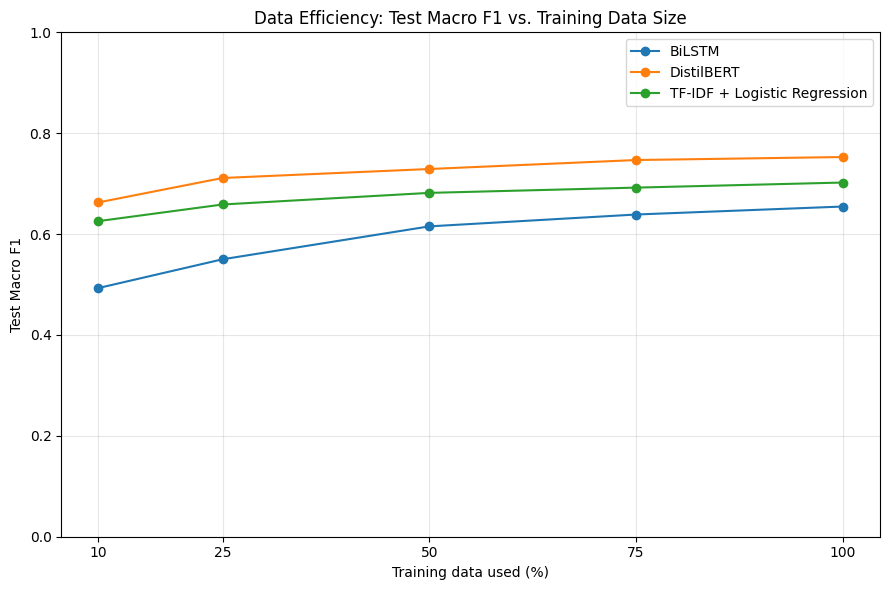

In [14]:
plt.figure(figsize=(9, 6))

for model_name, group in all_results.groupby("model"):
    group = group.sort_values("fraction")
    plt.plot(
        group["fraction"] * 100,
        group["test_macro_f1"],
        marker="o",
        label=model_name
    )

plt.xlabel("Training data used (%)")
plt.ylabel("Test Macro F1")
plt.title("Data Efficiency: Test Macro F1 vs. Training Data Size")
plt.xticks([10, 25, 50, 75, 100])
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# 8. Validation Macro F1

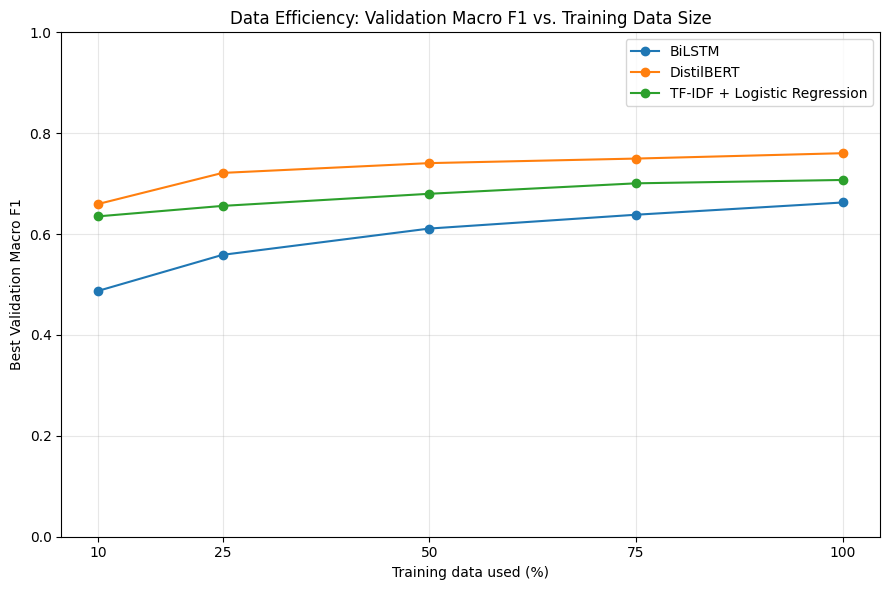

In [15]:
plt.figure(figsize=(9, 6))

for model_name, group in all_results.groupby("model"):
    group = group.sort_values("fraction")
    plt.plot(
        group["fraction"] * 100,
        group["val_macro_f1"],
        marker="o",
        label=model_name
    )

plt.xlabel("Training data used (%)")
plt.ylabel("Best Validation Macro F1")
plt.title("Data Efficiency: Validation Macro F1 vs. Training Data Size")
plt.xticks([10, 25, 50, 75, 100])
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# 9. Improvement from 10% to 100%

In [16]:
efficiency_summary = []

for model_name, group in all_results.groupby("model"):
    group = group.sort_values("fraction")

    f1_10 = group.loc[group["fraction"] == 0.10, "test_macro_f1"].iloc[0]
    f1_100 = group.loc[group["fraction"] == 1.00, "test_macro_f1"].iloc[0]

    efficiency_summary.append({
        "model": model_name,
        "macro_f1_at_10_percent": f1_10,
        "macro_f1_at_100_percent": f1_100,
        "absolute_gain": f1_100 - f1_10,
    })

efficiency_summary_df = pd.DataFrame(efficiency_summary)
display(efficiency_summary_df.round(4))


,model,macro_f1_at_10_percent,macro_f1_at_100_percent,absolute_gain
0,BiLSTM,0.4931,0.6546,0.1615
1,DistilBERT,0.6629,0.7528,0.0899
2,TF-IDF + Logistic Regression,0.6257,0.7022,0.0765


# 10. Save results

In [18]:
results_dir = DATA_DIR.parent / "results"
results_dir.mkdir(parents=True, exist_ok=True)

# Create the computational-cost table
cost_table = (
    all_results[
        ["model", "fraction", "n_train", "training_time_seconds"]
    ]
    .sort_values(["model", "fraction"])
    .copy()
)

# Convert seconds to minutes for easier interpretation
cost_table["training_time_minutes"] = (
    cost_table["training_time_seconds"] / 60
)

# Save all experiment results
all_results.to_csv(
    results_dir / "data_efficiency_results.csv",
    index=False
)

# Save the 10% vs 100% summary
efficiency_summary_df.to_csv(
    results_dir / "data_efficiency_summary.csv",
    index=False
)

# Save computational-cost results
cost_table.to_csv(
    results_dir / "data_efficiency_computational_cost.csv",
    index=False
)

print("Saved:")
print(results_dir / "data_efficiency_results.csv")
print(results_dir / "data_efficiency_summary.csv")
print(results_dir / "data_efficiency_computational_cost.csv")

Saved:
..\data\results\data_efficiency_results.csv
..\data\results\data_efficiency_summary.csv
..\data\results\data_efficiency_computational_cost.csv


# 11. Computational cost summary

Training time is recorded for every model and training-data fraction. This allows the data-efficiency result to be discussed together with computational cost, especially for DistilBERT.


In [19]:
cost_table = (
    all_results[["model", "fraction", "n_train", "training_time_seconds"]]
    .sort_values(["model", "fraction"])
    .copy()
)
cost_table["training_time_minutes"] = cost_table["training_time_seconds"] / 60
display(cost_table[["model", "fraction", "n_train", "training_time_minutes"]].round(2))


,model,fraction,n_train,training_time_minutes
0,BiLSTM,0.10,3811,0.23
1,BiLSTM,0.25,9529,0.33
2,BiLSTM,0.50,19058,0.53
3,BiLSTM,0.75,28586,0.84
4,BiLSTM,1.00,38115,1.14
5,DistilBERT,0.10,3811,4.68
6,DistilBERT,0.25,9529,8.42
7,DistilBERT,0.50,19058,14.69
8,DistilBERT,0.75,28586,20.97
9,DistilBERT,1.00,38115,27.37


# 12. Poster interpretation guide

Use the measured curves to answer RQ2.

Report:
1. How Macro F1 changes from 10% to 100%.
2. Whether performance begins to level off at a particular fraction.
3. Whether the three models show different data-efficiency patterns.
4. The computational cost of increasing training data, especially for DistilBERT.
5. The training-data fraction at which additional data produces relatively small gains, if such a pattern is observed.

Do not assume that more training data produces the same gain for every model. Base the final statement on the observed results.
Also avoid generalizing these results beyond this dataset and the experimental configurations used here.
